   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
(200, 5)

--- KNN Classifier ---
Accuracy: 0.9
Confusion Matrix:
 [[13  3  0]
 [ 0 17  1]
 [ 0  0  6]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.81      0.90        16
           1       0.85      0.94      0.89        18
           2       0.86      1.00      0.92         6

    accuracy                           0.90        40
   macro avg       0.90      0.92      0.90        40
weight

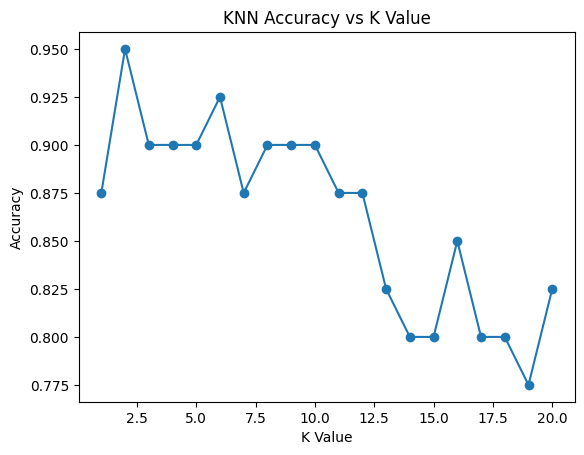

In [1]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ===============================
# LOAD DATASET
# ===============================
df = pd.read_csv("Mall_Customers.csv")

print(df.head())
print(df.columns)
print(df.shape)


# ===============================
# DATA PREPROCESSING
# ===============================
# Encode Genre column
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})


# ===============================
# CREATE TARGET (FOR CLASSIFICATION)
# ===============================
df['Spending_Category'] = pd.cut(
    df['Spending Score (1-100)'],
    bins=[0, 40, 70, 100],
    labels=[0, 1, 2]
)


# ===============================
# FEATURES & TARGET
# ===============================
X = df[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
y = df['Spending_Category']


# ===============================
# FEATURE SCALING
# ===============================
scaler = StandardScaler()
X = scaler.fit_transform(X)


# ===============================
# TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ===============================
# KNN CLASSIFIER
# ===============================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)


# ===============================
# PERFORMANCE EVALUATION
# ===============================
print("\n--- KNN Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


# ===============================
# HYPERPARAMETER TUNING (K VALUE)
# ===============================
k_values = range(1, 21)
accuracy_list = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred_k = model.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, pred_k))


plt.plot(k_values, accuracy_list, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K Value")
plt.show()
